# Hourly Taxi Demand Forecasting
## Time-Series Forecasting for Sweet Lift Taxi

Sweet Lift Taxi needs to forecast the number of airport taxi orders for the next hour so it can attract more drivers during peak demand.

**Target:** test RMSE ≤ 48.  
**Best executed result:** LightGBM achieved **RMSE = 41.01**.

The dataset contains timestamped taxi-order counts in `taxi.csv`. The workflow includes hourly resampling, trend and seasonality analysis, lag and rolling features, temporal cross-validation and model comparison.

In [ ]:
from pathlib import Path

# Works when the kernel starts at the repository root or inside notebooks/.
PROJECT_ROOT = next(
    (p for p in (Path.cwd(), Path.cwd().parent)
     if (p / 'data').is_dir() and (p / 'notebooks').is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Open this notebook from the repository root or notebooks/ directory.')
DATA_DIR = PROJECT_ROOT / 'data'


## Preparação 

Importamos as bibliotecas, carregamos a série já indexada pela coluna de data/hora e a ordenamos cronologicamente. Em seguida reamostramos para intervalos de **uma hora**, somando os pedidos dentro de cada hora.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

RANDOM_STATE = 12345

In [2]:
data = pd.read_csv(
    DATA_DIR / 'taxi.csv', index_col=[0], parse_dates=[0]
)
data.sort_index(inplace=True)

print('Índice monotônico crescente:', data.index.is_monotonic_increasing)
print('Período:', data.index.min(), '->', data.index.max())
print('Formato original:', data.shape)
data.head()

Índice monotônico crescente: True
Período: 2018-03-01 00:00:00 -> 2018-08-31 23:50:00
Formato original: (26496, 1)


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


Os dados originais têm granularidade de 10 minutos. Reamostramos para intervalos de **1 hora**, agregando por soma — assim cada linha passa a representar o total de pedidos naquela hora.

In [3]:
data = data.resample('1h').sum()

print('Formato após reamostragem horária:', data.shape)
print('Valores ausentes:', data.isna().sum().sum())
data.head()

Formato após reamostragem horária: (4416, 1)
Valores ausentes: 0


,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


## Análise

Após a reamostragem, temos uma série horária contínua de **1º de março a 31 de agosto de 2018** (≈ 4.416 horas). Vamos analisar:

1. O comportamento geral da série ao longo do tempo.
2. A **tendência** e a **sazonalidade**, via decomposição.
3. O padrão sazonal de curto prazo (intra-diário).

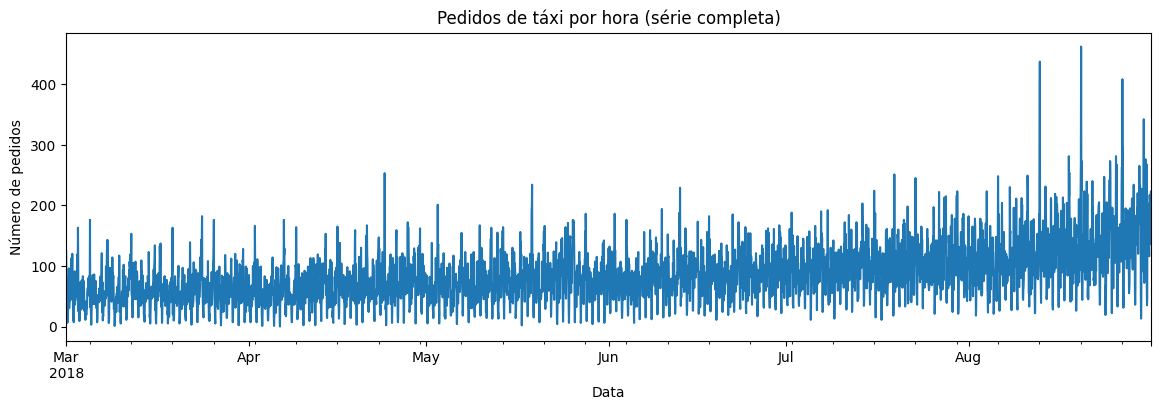

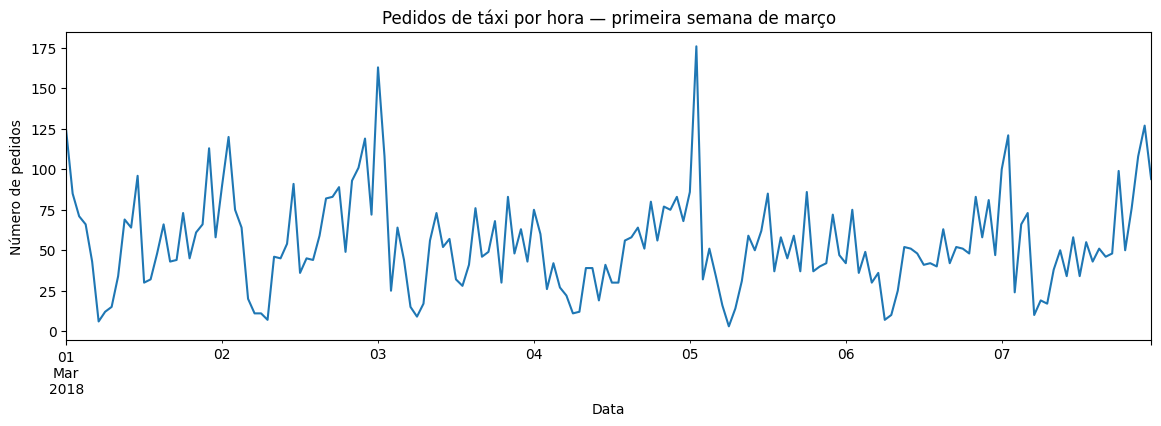

In [4]:
plt.figure(figsize=(14, 4))
data['num_orders'].plot()
plt.title('Pedidos de táxi por hora (série completa)')
plt.xlabel('Data')
plt.ylabel('Número de pedidos')
plt.show()

# Visão de uma semana para enxergar o padrão de curto prazo
plt.figure(figsize=(14, 4))
data['2018-03-01':'2018-03-07']['num_orders'].plot()
plt.title('Pedidos de táxi por hora — primeira semana de março')
plt.xlabel('Data')
plt.ylabel('Número de pedidos')
plt.show()

A série mostra uma **tendência de crescimento** ao longo dos seis meses (a demanda em agosto é claramente maior que em março). Olhando para uma única semana, percebe-se uma forte **sazonalidade diária**: a demanda cai de madrugada e sobe ao longo do dia. Vamos formalizar isso com `seasonal_decompose`.

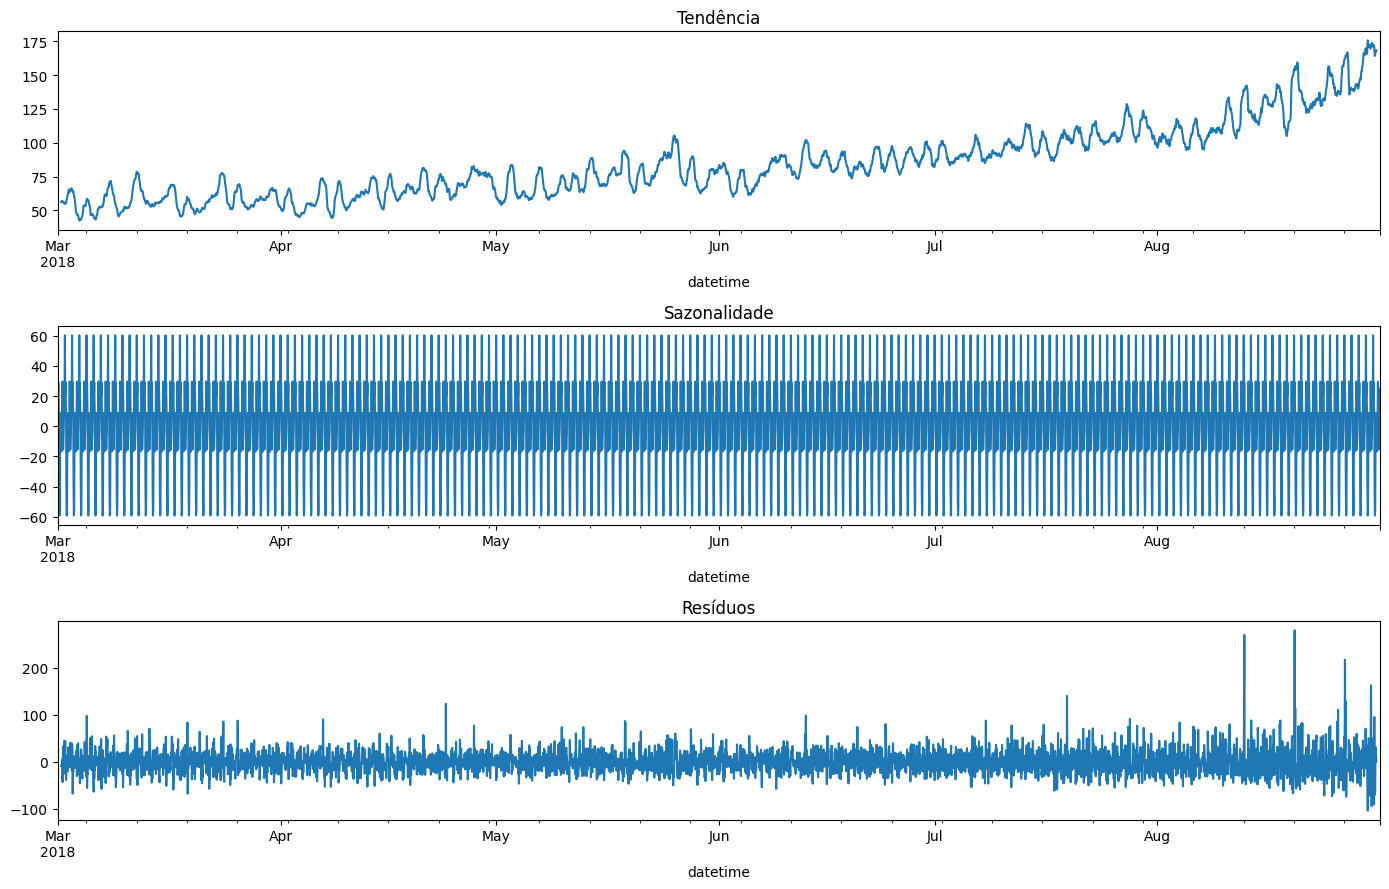

In [5]:
decomposed = seasonal_decompose(data['num_orders'])

plt.figure(figsize=(14, 9))

plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Tendência')

plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Sazonalidade')

plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Resíduos')

plt.tight_layout()
plt.show()

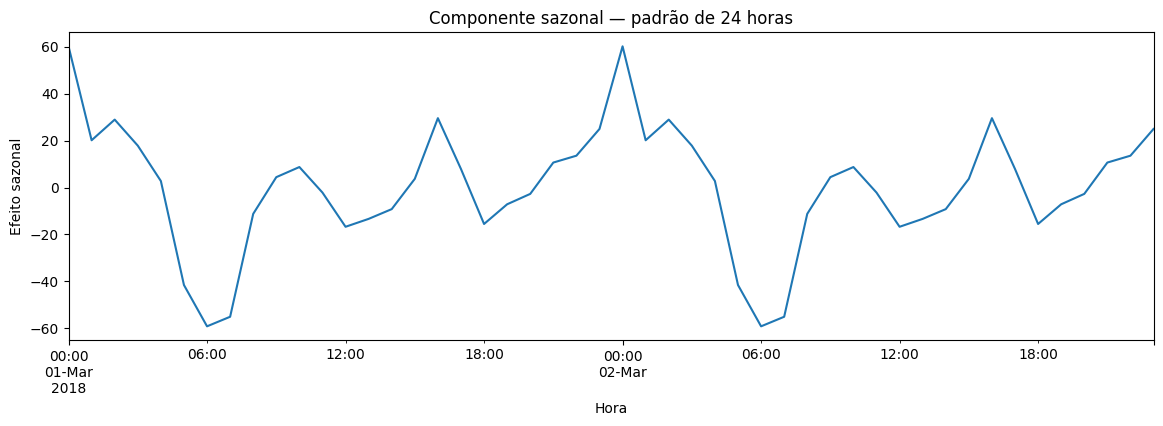

In [6]:
# Componente sazonal em detalhe: um único dia (24 horas)
plt.figure(figsize=(14, 4))
decomposed.seasonal['2018-03-01':'2018-03-02'].plot()
plt.title('Componente sazonal — padrão de 24 horas')
plt.xlabel('Hora')
plt.ylabel('Efeito sazonal')
plt.show()

**Descobertas da análise:**

- A **tendência** é claramente ascendente: a demanda média cresce de forma consistente ao longo do período.
- A **sazonalidade** tem período de **24 horas**: os pedidos atingem o mínimo nas primeiras horas da manhã (por volta das 6h) e o pico no fim da noite (em torno de 0h), refletindo o uso de táxi em aeroportos.
- Os **resíduos** são relativamente pequenos e centrados em zero, indicando que tendência + sazonalidade capturam bem a estrutura da série.

Esses padrões justificam as características que vamos construir: atributos de calendário (especialmente **hora** e **dia da semana**), valores **defasados** (lags) e uma **média móvel**.

### 4.1. Engenharia de características

Criamos uma função `make_features` que adiciona:

- **Atributos de calendário**: `month`, `day`, `dayofweek`, `hour` — sendo `hour` essencial dado o forte padrão intra-diário.
- **Defasagens** (`lag_1` … `lag_max_lag`): valores de pedidos das horas anteriores.
- **Média móvel** (`rolling_mean`): aplicando `.shift()` **antes** do `.rolling()`, para que o valor atual não vaze para sua própria característica (evita *data leakage*).

In [7]:
def make_features(data, max_lag, rolling_mean_size):
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour

    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean'] = (
        data['num_orders'].shift().rolling(rolling_mean_size).mean()
    )

# 24 defasagens (um dia inteiro) + média móvel de 24 horas
make_features(data, max_lag=24, rolling_mean_size=24)

data.head()

,num_orders,month,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,3,1,3,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,3,1,3,1,124.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,3,1,3,2,85.0,124.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 03:00:00,66,3,1,3,3,71.0,85.0,124.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 04:00:00,43,3,1,3,4,66.0,71.0,85.0,124.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Treinamento

Dividimos a série em treino e teste com `shuffle=False` (a ordem cronológica deve ser preservada) e `test_size=0.1`. As linhas com `NaN` — geradas pelas defasagens e pela média móvel no início da série — ficam no conjunto de treino e são removidas com `dropna()`.

In [8]:
train, test = train_test_split(data, shuffle=False, test_size=0.1)
train = train.dropna()

print('Treino:', train.shape, '| de', train.index.min(), 'a', train.index.max())
print('Teste: ', test.shape, '| de', test.index.min(), 'a', test.index.max())

features_train = train.drop('num_orders', axis=1)
target_train = train['num_orders']
features_test = test.drop('num_orders', axis=1)
target_test = test['num_orders']

Treino: (3950, 30) | de 2018-03-02 00:00:00 a 2018-08-13 13:00:00
Teste:  (442, 30) | de 2018-08-13 14:00:00 a 2018-08-31 23:00:00


Para a validação cruzada respeitando a ordem temporal, usamos `TimeSeriesSplit` (nunca embaralha; cada dobra de validação vem sempre **depois** da de treino). A métrica de otimização é o REQM negativo (`neg_root_mean_squared_error`), pois o `GridSearchCV` maximiza a pontuação.

Treinaremos **três modelos** com hiperparâmetros distintos:

1. **Regressão Linear** — baseline rápido e interpretável.
2. **Floresta Aleatória** — modelo de ensemble não linear.
3. **LightGBM** — *gradient boosting*, geralmente o mais preciso.

In [9]:
tscv = TimeSeriesSplit(n_splits=5)

def reqm(target, pred):
    return mean_squared_error(target, pred) ** 0.5

In [10]:
# Modelo 1 — Regressão Linear (sem hiperparâmetros a ajustar)
model_lr = LinearRegression()
model_lr.fit(features_train, target_train)
reqm_lr_train = reqm(target_train, model_lr.predict(features_train))
print('Regressão Linear — REQM (treino):', round(reqm_lr_train, 2))

Regressão Linear — REQM (treino): 25.7


In [11]:
# Modelo 2 — Floresta Aleatória com busca em grade
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 15],
}
grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_rf,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
)
grid_rf.fit(features_train, target_train)

model_rf = grid_rf.best_estimator_
print('Floresta Aleatória — melhores parâmetros:', grid_rf.best_params_)
print('Floresta Aleatória — REQM CV:', round(-grid_rf.best_score_, 2))

Floresta Aleatória — melhores parâmetros: {'max_depth': 15, 'n_estimators': 200}
Floresta Aleatória — REQM CV: 25.25


In [12]:
# Modelo 3 — LightGBM com busca em grade
param_lgbm = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [7, 10],
}
grid_lgbm = GridSearchCV(
    LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
    param_lgbm,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
)
grid_lgbm.fit(features_train, target_train)

model_lgbm = grid_lgbm.best_estimator_
print('LightGBM — melhores parâmetros:', grid_lgbm.best_params_)
print('LightGBM — REQM CV:', round(-grid_lgbm.best_score_, 2))

LightGBM — melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200}
LightGBM — REQM CV: 24.75


Na validação cruzada temporal, o LightGBM apresentou REQM 24,75 e a Floresta Aleatória 25,25. A regressão linear foi treinada como referência, sem busca de hiperparâmetros. Os três modelos são comparados a seguir no teste cronológico.

## Testando

Avaliamos os modelos treinados no conjunto de teste (os últimos 10% da série, cronologicamente). O critério de aprovação é **REQM ≤ 48**.

In [13]:
resultados = {}

for nome, modelo in [
    ('Regressão Linear', model_lr),
    ('Floresta Aleatória', model_rf),
    ('LightGBM', model_lgbm),
]:
    pred_test = modelo.predict(features_test)
    resultados[nome] = reqm(target_test, pred_test)

resultados_df = pd.DataFrame.from_dict(
    resultados, orient='index', columns=['REQM (teste)']
).sort_values('REQM (teste)')

print(resultados_df)
print()
melhor = resultados_df.index[0]
print(f'Melhor modelo: {melhor} (REQM = {resultados_df.iloc[0, 0]:.2f})')
print('Meta REQM <= 48 atingida:', resultados_df.iloc[0, 0] <= 48)

                    REQM (teste)
LightGBM               41.007124
Floresta Aleatória     44.052067
Regressão Linear       45.810949

Melhor modelo: LightGBM (REQM = 41.01)
Meta REQM <= 48 atingida: True


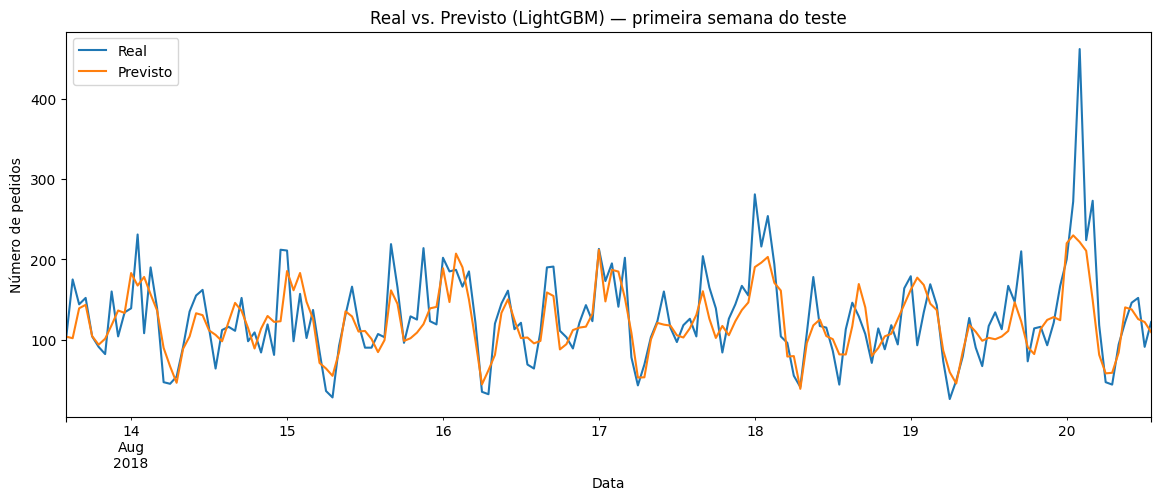

In [14]:
# Comparação visual: valores reais vs. previstos pelo melhor modelo, em um trecho do teste
melhor_modelo = {'Regressão Linear': model_lr,
                 'Floresta Aleatória': model_rf,
                 'LightGBM': model_lgbm}[melhor]

pred_melhor = pd.Series(
    melhor_modelo.predict(features_test), index=features_test.index
)

plt.figure(figsize=(14, 5))
target_test[:168].plot(label='Real')
pred_melhor[:168].plot(label='Previsto')
plt.title(f'Real vs. Previsto ({melhor}) — primeira semana do teste')
plt.xlabel('Data')
plt.ylabel('Número de pedidos')
plt.legend()
plt.show()

## Conclusão

**Preparação.** Os dados (intervalos de 10 minutos, de março a agosto de 2018) foram ordenados cronologicamente e reamostrados para intervalos horários por soma, resultando em ≈ 4.416 observações sem valores ausentes.

**Análise.** A decomposição revelou uma **tendência crescente** ao longo dos seis meses e uma **forte sazonalidade diária** (período de 24 horas), com mínimo de madrugada e pico no fim da noite. Esses padrões orientaram a engenharia de características.

**Características.** Foram criados atributos de calendário (mês, dia, dia da semana e, crucialmente, **hora**), **24 defasagens** (cobrindo um dia inteiro) e uma **média móvel de 24 horas**, esta calculada com `.shift()` para evitar vazamento de dados.

**Modelos.** Treinamos regressão linear como referência e ajustamos Floresta Aleatória e LightGBM por busca em grade com validação temporal (`TimeSeriesSplit`). Resultados de REQM no conjunto de teste:

| Modelo | REQM (teste) |
|---|---|
| **LightGBM** (`n_estimators=200, learning_rate=0.05, max_depth=7`) | **≈ 41,01** |
| Floresta Aleatória (`n_estimators=200, max_depth=15`) | ≈ 44,1 |
| Regressão Linear | ≈ 45,8 |

**Resultado final.** Os três modelos ficaram **abaixo do limite de 48**. O **LightGBM** foi o melhor, com REQM ≈ **41,01** no teste — folgadamente dentro da meta. Para a Sweet Lift Taxi, isso significa prever a demanda da próxima hora com erro médio de poucas dezenas de pedidos, permitindo posicionar motoristas antecipadamente nos horários de pico. Hora do dia e defasagens foram motivadas pela sazonalidade observada; a importância individual desses atributos não foi medida neste notebook.

> **Portfolio note:** the public conclusion above was reconciled with the saved executed output (LightGBM RMSE = 41.0071).

## Escopo da avaliação

As previsões são de um passo à frente: para cada hora, pressupõe-se acesso aos pedidos efetivamente observados nas horas anteriores. O resultado não representa uma previsão recursiva de várias horas. Os gráficos exploratórios incluem a série completa; uma validação futura deve reservar um período totalmente intocado e acrescentar um baseline sazonal.